In [1]:
import pandas as pd
import matplotlib.pyplot as plt

http_df=pd.read_csv("../data/r4.2/http.csv", nrows=300000)
http_df.head()

,id,date,user,pc,url,content
0,{V1Y4-S2IR20QU-6154HFXJ},01/02/2010 06:55:16,LRR0148,PC-4275,http://msn.com/The_Human_Centipede_First_Seque...,remain representatives consensus concert altho...
1,{Q5R1-T3EF87UE-2395RWZS},01/02/2010 07:00:13,NGF0157,PC-6056,http://urbanspoon.com/Plunketts_Creek_Loyalsoc...,festival off northwards than congestion partne...
2,{X9O1-O0XW52VO-5806RPHG},01/02/2010 07:03:46,NGF0157,PC-6056,http://aa.com/Rhodocene/rhodocenium/fhaavatqrf...,long away reorganized baldwin seth business 18...
3,{G5S8-U5OG04TE-5299CCTU},01/02/2010 07:05:26,IRM0931,PC-7188,http://groupon.com/Leonhard_Euler/leonhard/tne...,among german schwein experimental becomes prev...
4,{L0R4-A9DH29VP-4553AUWM},01/02/2010 07:05:52,IRM0931,PC-7188,http://flickr.com/Inauguration_of_Barack_Obama...,kate criteria j 2008 highest 12 include books ...


In [2]:
# Websites Visited per User
websites_per_user = http_df.groupby("user").size().sort_values(ascending=False)

print(websites_per_user.head(10))

user
MSS0001    1416
KBP0008    1078
HTH0007     984
TVS0006     981
KWC0004     966
BTW0005     964
HCS0003     957
AJR0319     873
RZC0746     864
DLM0051     838
dtype: int64


In [3]:
# url Frequency
domain_counts = http_df["url"].value_counts()

print(domain_counts.head(20))

url
http://nfl.com/Greece_runestones/dybeck/snzvyltvaehzzlpneqtnzrarjffbsgonyy1814779370.jsp                                         5327
http://linkedin.com/Harry_Chauvel/chetwode/cebwrpg757315014.jsp                                                                  3829
http://eonline.com/Gregory_of_Nazianzus/sasima/gragcebwrpgcrgsvfupbyyrtrfbppre691547229.htm                                      3822
http://inbox.com/Cheadle_Hulme/hulme/yrnqrefuvcnanylfvfselvat513824541.aspx                                                      3202
http://ebay.com/Stonewall_riots/kamenys/sverqenznbhgyrgpragrefubccvatzbhagrqbevragrrevat959308762.php                            3191
http://shareasale.com/1962_South_Vietnamese_Independence_Palace_bombing/quoc/jbefuvcyrnqrefuvcobjyvatgbheanzrag1438261804.php    2747
http://outbrain.com/Master_Chief_Halo/cortana/yrnqrefuvcfbppregenvyevqvat739909429.jsp                                           2720
http://wellsfargo.com/Benjamin_Harrison/harrisons/ynoahgev

<Axes: xlabel='date'>

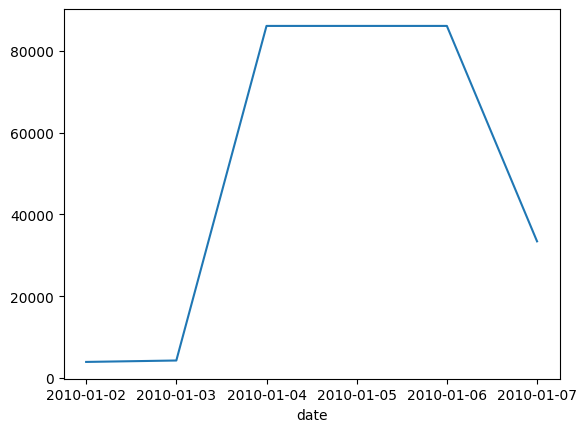

In [4]:
#Browsing Activity Over Time
http_df["date"] = pd.to_datetime(http_df["date"])

daily_browsing = http_df.groupby(http_df["date"].dt.date).size()

daily_browsing.plot()

In [5]:
# night time Browsing Activity
http_df["hour"] = http_df["date"].dt.hour

night_activity = http_df[(http_df["hour"] > 18) | (http_df["hour"] < 6)]

night_users = night_activity.groupby("user").size()

print(night_users.sort_values(ascending=False).head())

user
GTD0116    89
COF0120    77
WKD0013    74
HRL0540    70
BRM0995    69
dtype: int64


In [6]:
# Suspicious Website Categories
suspicious_sites = ["dropbox","drive","mega","pastebin","github"]

http_df["suspicious"] = http_df["url"].str.contains("|".join(suspicious_sites), case=False)

http_df[http_df["suspicious"]].groupby("user").size().sort_values(ascending=False)

user
KCF0045    51
CCA0046    50
MKS0204    48
MSO0222    45
FAW0032    40
           ..
PAD0773     1
JMK0099     1
OLW0689     1
JMW0638     1
ZKS0899     1
Length: 273, dtype: int64

In [7]:
websites_per_user = http_df.groupby("user").size().sort_values(ascending=False)

print(websites_per_user.head(10))

user
MSS0001    1416
KBP0008    1078
HTH0007     984
TVS0006     981
KWC0004     966
BTW0005     964
HCS0003     957
AJR0319     873
RZC0746     864
DLM0051     838
dtype: int64


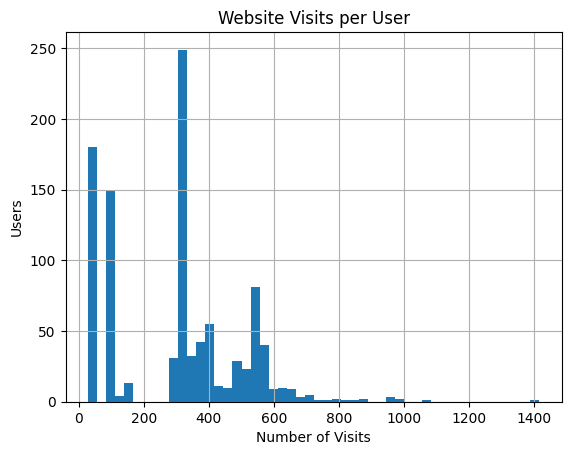

In [11]:
import matplotlib.pyplot as plt

websites_per_user.hist(bins=50)

plt.title("Website Visits per User")
plt.xlabel("Number of Visits")
plt.ylabel("Users")
plt.show()

In [12]:
websites_per_user = http_df.groupby("user").size().reset_index(name="visit_count")

In [13]:
print(websites_per_user)

        user  visit_count
0    AAE0190          472
1    AAF0535           93
2    AAF0791          322
3    AAL0706           34
4    AAM0658           91
..       ...          ...
995  ZKS0899           94
996  ZMC0284          307
997  ZSB0649           94
998  ZSK0258          314
999  ZSL0305           34

[1000 rows x 2 columns]
